In [ ]:
# Install library (jalankan sekali)
!pip install matplotlib

✓ Library berhasil diimport
✓ Siap menjalankan pipeline

   PIPELINE ANALISIS GC CONTENT SEKUENS DNA

[1] Silakan upload file FASTA atau FASTQ dari NCBI...
    (Klik tombol 'Choose Files' yang akan muncul di bawah)



Saving sequence NC_001802.1.FASTA to sequence NC_001802.1 (4).FASTA

  ✓ File diterima  : sequence NC_001802.1 (4).FASTA
  ✓ Ukuran file    : 13,350 bytes

[2] Membaca file .FASTA...
  ✓ Format         : FASTA
  ✓ Total sekuens  : 10

[3] Menghitung frekuensi nukleotida & GC content...
  ✓ Semua 10 sekuens diproses dan diurutkan.

[4] Menampilkan 3 sekuens terbaik...

   TOP 3 SEKUENS — GC CONTENT TERTINGGI

  ┌─ Rank #1
  │  Header   : lcl|NC_001802.1_cds_NP_057854.1_6 [gene=rev] [locus_tag=HIV1gp6] ...
  │  Panjang  : 351 bp
  │  GC (%)   : 51.28%
  └─ Frek     : A=105  T=66  G=99  C=81

  ┌─ Rank #2
  │  Header   : lcl|NC_001802.1_cds_NP_057857.2_10 [gene=nef] [locus_tag=HIV1gp9]...
  │  Panjang  : 621 bp
  │  GC (%)   : 49.44%
  └─ Frek     : A=190  T=124  G=175  C=132

  ┌─ Rank #3
  │  Header   : lcl|NC_001802.1_cds_NP_057853.1_5 [gene=tat] [locus_tag=HIV1gp5] ...
  │  Panjang  : 261 bp
  │  GC (%)   : 48.66%
  └─ Frek     : A=82  T=52  G=59  C=68


[5] Membuat grafik GC Content.

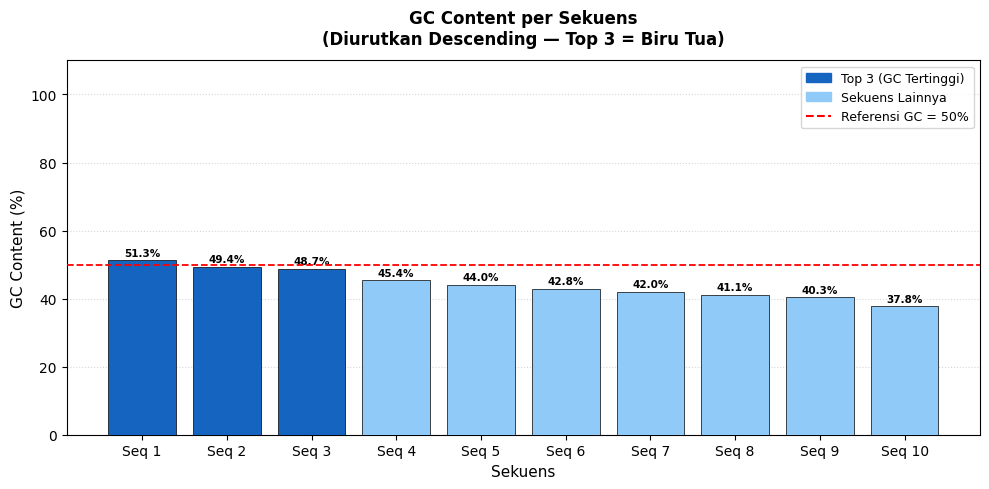


  ✓ Grafik disimpan: gc_content_sequence NC_001802.1 (4).png

[6] Menyimpan hasil ke CSV...
  ✓ File CSV disimpan: hasil_analisis_sequence NC_001802.1 (4).csv

[7] Mengunduh hasil ke komputer Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ File CSV dan PNG berhasil didownload!

  ✓ PIPELINE SELESAI!
Rank    GC Content   Panjang (bp)  Header (50 karakter pertama)
------------------------------------------------------------------------------------------
1           51.28%            351  lcl|NC_001802.1_cds_NP_057854.1_6 [gene=rev] [locu...
2           49.44%            621  lcl|NC_001802.1_cds_NP_057857.2_10 [gene=nef] [loc...
3           48.66%            261  lcl|NC_001802.1_cds_NP_057853.1_5 [gene=tat] [locu...
4           45.36%            291  lcl|NC_001802.1_cds_NP_057852.2_4 [gene=vpr] [locu...
5           44.05%          1,503  lcl|NC_001802.1_cds_NP_057850.1_2 [gene=gag] [locu...
6           42.81%            570  lcl|NC_001802.1_cds_YP_009028572.1_9 [gene=asp] [l...
7           41.97%            579  lcl|NC_001802.1_cds_NP_057851.1_3 [gene=vif] [locu...
8           41.07%          2,571  lcl|NC_001802.1_cds_NP_057856.1_8 [gene=env] [locu...
9           40.34%          4,308  lcl|NC_001802.1_cds_NP_057849.4_1

In [5]:
# ================================================================
# Import & Definisi Fungsi
# ================================================================

import csv
import io
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import files

print("✓ Library berhasil diimport")
print("✓ Siap menjalankan pipeline\n")


# ------------------------------------------------------------------
# MODUL 1: Membaca file FASTA → disimpan dalam LIST
# ------------------------------------------------------------------

def read_fasta_from_bytes(file_bytes):
    """
    Membaca konten file FASTA dari bytes (hasil upload Colab).
    Menyimpan data dalam struktur LIST of dict.
    Kompleksitas: O(n) di mana n = total karakter file
    """
    sequences = []           # Struktur data: LIST
    current_header = None
    current_seq = []

    # Decode bytes ke string, lalu proses per baris
    content = file_bytes.decode('utf-8', errors='ignore')
    for line in content.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith('>'):
            if current_header is not None:
                sequences.append((current_header, ''.join(current_seq)))
            current_header = line[1:]   # Hapus karakter '>'
            current_seq = []
        else:
            current_seq.append(line.upper())

    # Simpan sekuens terakhir
    if current_header is not None:
        sequences.append((current_header, ''.join(current_seq)))

    return sequences  # LIST of tuples


def read_fastq_from_bytes(file_bytes):
    """
    Membaca konten file FASTQ dari bytes (hasil upload Colab).
    Format FASTQ: setiap 4 baris = 1 read
      Baris 1: header (@...)
      Baris 2: sequence
      Baris 3: '+' (separator)
      Baris 4: quality score
    Kompleksitas: O(n)
    """
    sequences = []   # Struktur data: LIST
    content   = file_bytes.decode('utf-8', errors='ignore')
    lines     = [l.strip() for l in content.splitlines() if l.strip()]

    i = 0
    while i + 3 < len(lines):
        header  = lines[i].lstrip('@')
        seq     = lines[i + 1].upper()
        # lines[i+2] adalah '+', skip
        # lines[i+3] adalah quality score, skip (tidak dipakai di sini)
        sequences.append((header, seq))
        i += 4

    return sequences


# ------------------------------------------------------------------
# MODUL 2: Hitung Frekuensi Nukleotida → DICTIONARY
# ------------------------------------------------------------------

def hitung_frekuensi_nukleotida(sequence):
    """
    Struktur data: DICTIONARY (Hash Map)
    Key  = nukleotida (A/T/G/C)
    Value = jumlah kemunculan
    Kompleksitas: O(n)
    """
    freq = {'A': 0, 'T': 0, 'G': 0, 'C': 0}
    for nuc in sequence:
        if nuc in freq:
            freq[nuc] += 1
    return freq  # DICTIONARY


# ------------------------------------------------------------------
# MODUL 3: Hitung GC Content
# ------------------------------------------------------------------

def hitung_gc_content(sequence):
    """
    GC Content (%) = (jumlah G + jumlah C) / panjang_total × 100
    """
    if len(sequence) == 0:
        return 0.0
    gc = sequence.count('G') + sequence.count('C')
    return (gc / len(sequence)) * 100


# ------------------------------------------------------------------
# MODUL 4: Proses & Urutkan berdasarkan GC Content (Descending)
# ------------------------------------------------------------------

def proses_dan_urutkan(sequences):
    """
    Menghasilkan LIST of DICTIONARY dengan informasi lengkap.
    Diurutkan descending menggunakan Timsort: O(n log n)
    """
    hasil = []
    for header, seq in sequences:
        gc   = hitung_gc_content(seq)
        freq = hitung_frekuensi_nukleotida(seq)
        hasil.append({
            'header'    : header,
            'sequence'  : seq,
            'panjang'   : len(seq),
            'gc_content': gc,
            'freq'      : freq
        })

    hasil.sort(key=lambda x: x['gc_content'], reverse=True)
    return hasil


# ------------------------------------------------------------------
# MODUL 5: Tampilkan Top 3 Sekuens (GC Tertinggi)
# ------------------------------------------------------------------

def tampilkan_top3(sorted_sequences):
    print("\n" + "="*65)
    print("   TOP 3 SEKUENS — GC CONTENT TERTINGGI")
    print("="*65)

    top3 = sorted_sequences[:3]
    for i, data in enumerate(top3, 1):
        hdr = data['header']
        hdr_display = hdr[:65] + ('...' if len(hdr) > 65 else '')
        f   = data['freq']
        print(f"\n  ┌─ Rank #{i}")
        print(f"  │  Header   : {hdr_display}")
        print(f"  │  Panjang  : {data['panjang']:,} bp")
        print(f"  │  GC (%)   : {data['gc_content']:.2f}%")
        print(f"  └─ Frek     : A={f['A']:,}  T={f['T']:,}  G={f['G']:,}  C={f['C']:,}")

    print("\n" + "="*65)


# ------------------------------------------------------------------
# MODUL 6: Visualisasi Bar Chart GC Content
# ------------------------------------------------------------------

def visualisasi_gc(sorted_sequences, output_file='gc_content_plot.png'):
    """
    Bar chart semua sekuens — Top 3 ditandai warna biru tua.
    Plot ditampilkan inline di Colab dan disimpan sebagai PNG.
    """
    n      = len(sorted_sequences)
    labels = [f"Seq {i+1}" for i in range(n)]
    gc_val = [s['gc_content'] for s in sorted_sequences]
    colors = ['#1565C0' if i < 3 else '#90CAF9' for i in range(n)]

    fig_width = max(10, n * 0.9)
    fig, ax   = plt.subplots(figsize=(fig_width, 5))

    bars = ax.bar(labels, gc_val, color=colors, edgecolor='black', linewidth=0.5, zorder=3)

    # Garis referensi 50%
    ax.axhline(y=50, color='red', linestyle='--', linewidth=1.3, zorder=4)

    # Label nilai di atas bar
    for bar, val in zip(bars, gc_val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold'
        )

    ax.set_xlabel('Sekuens', fontsize=11)
    ax.set_ylabel('GC Content (%)', fontsize=11)
    ax.set_title('GC Content per Sekuens\n(Diurutkan Descending — Top 3 = Biru Tua)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_ylim(0, 110)
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)

    top3_p  = mpatches.Patch(color='#1565C0', label='Top 3 (GC Tertinggi)')
    other_p = mpatches.Patch(color='#90CAF9', label='Sekuens Lainnya')
    ref_l   = plt.Line2D([0], [0], color='red', linestyle='--', label='Referensi GC = 50%')
    ax.legend(handles=[top3_p, other_p, ref_l], fontsize=9, loc='upper right')

    if n > 12:
        plt.xticks(rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  ✓ Grafik disimpan: {output_file}")


# ------------------------------------------------------------------
# MODUL 7: Simpan Hasil ke CSV
# ------------------------------------------------------------------

def simpan_ke_csv(sorted_sequences, output_file='hasil_analisis.csv'):
    """
    Kolom: Rank | Header | Panjang_bp | GC_Content_% | A | T | G | C
    """
    fieldnames = ['Rank', 'Header', 'Panjang_bp', 'GC_Content_%', 'A', 'T', 'G', 'C']

    with open(output_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for i, s in enumerate(sorted_sequences, 1):
            writer.writerow({
                'Rank'         : i,
                'Header'       : s['header'],
                'Panjang_bp'   : s['panjang'],
                'GC_Content_%' : round(s['gc_content'], 2),
                'A'            : s['freq']['A'],
                'T'            : s['freq']['T'],
                'G'            : s['freq']['G'],
                'C'            : s['freq']['C']
            })

    print(f"  ✓ File CSV disimpan: {output_file}")


# ================================================================
# UPLOAD FILE & JALANKAN PIPELINE
# ================================================================

def jalankan_pipeline():
    print("="*65)
    print("   PIPELINE ANALISIS GC CONTENT SEKUENS DNA")
    print("="*65)

    # [1] Upload File
    print("\n[1] Silakan upload file FASTA atau FASTQ dari NCBI...")
    print("    (Klik tombol 'Choose Files' yang akan muncul di bawah)\n")

    uploaded = files.upload()

    if not uploaded:
        print("✗ Tidak ada file yang diupload. Pipeline dibatalkan.")
        return

    filename    = list(uploaded.keys())[0]
    file_bytes  = uploaded[filename]
    ext         = os.path.splitext(filename)[1].lower()

    print(f"\n  ✓ File diterima  : {filename}")
    print(f"  ✓ Ukuran file    : {len(file_bytes):,} bytes")

    # [2] Baca File sesuai format
    print(f"\n[2] Membaca file {ext.upper()}...")

    if ext in ['.fasta', '.fa', '.fna', '.ffn', '.faa', '.frn']:
        sequences = read_fasta_from_bytes(file_bytes)
        fmt = "FASTA"
    elif ext in ['.fastq', '.fq']:
        sequences = read_fastq_from_bytes(file_bytes)
        fmt = "FASTQ"
    else:
        sample = file_bytes[:200].decode('utf-8', errors='ignore')
        if sample.startswith('>'):
            sequences = read_fasta_from_bytes(file_bytes)
            fmt = "FASTA (terdeteksi otomatis)"
        elif sample.startswith('@'):
            sequences = read_fastq_from_bytes(file_bytes)
            fmt = "FASTQ (terdeteksi otomatis)"
        else:
            print("✗ Format file tidak dikenali. Gunakan .fasta atau .fastq")
            return

    if not sequences:
        print("✗ Tidak ada sekuens yang berhasil dibaca. Cek format file.")
        return

    print(f"  ✓ Format         : {fmt}")
    print(f"  ✓ Total sekuens  : {len(sequences)}")

    # [3] Proses & Urutkan
    print("\n[3] Menghitung frekuensi nukleotida & GC content...")
    sorted_seqs = proses_dan_urutkan(sequences)
    print(f"  ✓ Semua {len(sorted_seqs)} sekuens diproses dan diurutkan.")

    # [4] Tampilkan Top 3
    print("\n[4] Menampilkan 3 sekuens terbaik...")
    tampilkan_top3(sorted_seqs)

    # [5] Visualisasi
    print("\n[5] Membuat grafik GC Content...")
    nama_plot = f"gc_content_{os.path.splitext(filename)[0]}.png"
    visualisasi_gc(sorted_seqs, output_file=nama_plot)

    # [6] Simpan CSV
    print("\n[6] Menyimpan hasil ke CSV...")
    nama_csv = f"hasil_analisis_{os.path.splitext(filename)[0]}.csv"
    simpan_ke_csv(sorted_seqs, output_file=nama_csv)

    # [7] Download output ke komputer
    print("\n[7] Mengunduh hasil ke komputer Anda...")
    files.download(nama_csv)
    files.download(nama_plot)
    print("  ✓ File CSV dan PNG berhasil didownload!\n")

    print("="*65)
    print("  ✓ PIPELINE SELESAI!")
    print("="*65)

    return sorted_seqs   # return agar bisa dipakai lebih lanjut



# Jalankan pipeline
hasil = jalankan_pipeline()

if hasil:
    print(f"{'Rank':<5} {'GC Content':>12} {'Panjang (bp)':>14}  {'Header (50 karakter pertama)'}")
    print('-' * 90)
    for i, s in enumerate(hasil, 1):
        hdr = s['header'][:50] + ('...' if len(s['header']) > 50 else '')
        print(f"{i:<5} {s['gc_content']:>11.2f}% {s['panjang']:>14,}  {hdr}")
else:
    print('Pipeline belum dijalankan. Jalankan Cell 6 terlebih dahulu.')